# Customer Churn Analysis – Financial Impact

## Objective
This analysis evaluates the financial impact of customer churn using the Telco Customer Churn dataset. The goal is to estimate how much monthly revenue is associated with churned customers and identify why churn is financially important for the business.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Preparation
The dataset was loaded and cleaned before the financial analysis. The `TotalCharges` column was converted to numeric format, and rows with missing values were removed to ensure consistency in the calculations.

In [4]:
total_revenue = df['MonthlyCharges'].sum()

churned = df[df['Churn'] == 'Yes']
active = df[df['Churn'] == 'No']

lost_revenue = churned['MonthlyCharges'].sum()
active_revenue = active['MonthlyCharges'].sum()

loss_percentage = (lost_revenue / total_revenue) * 100

print("Total Monthly Revenue:", round(total_revenue, 2))
print("Active Customer Revenue:", round(active_revenue, 2))
print("Lost Monthly Revenue (Churned Customers):", round(lost_revenue, 2))
print("Revenue Loss Percentage:", round(loss_percentage, 2), "%")

Total Monthly Revenue: 455661.0
Active Customer Revenue: 316530.15
Lost Monthly Revenue (Churned Customers): 139130.85
Revenue Loss Percentage: 30.53 %


## Revenue Overview
This section compares total monthly revenue generated by all customers with the portion associated with churned customers. This helps measure the direct financial exposure linked to customer attrition.

In [ ]:
labels = ['Active Customers', 'Churned Customers']
values = [active_revenue, lost_revenue]

plt.bar(labels, values)
plt.title("Revenue Comparison: Active vs Churned Customers")
plt.ylabel("Monthly Revenue")
plt.show()

## Interpretation
The chart shows that churned customers represent a substantial share of the company’s monthly revenue. Even though active customers still generate the majority of revenue, the value associated with churned customers is large enough to create meaningful financial pressure on the business.

This means churn is not only a customer retention issue, but also a revenue protection issue.

In [5]:
revenue_by_contract = df.groupby('Contract')['MonthlyCharges'].sum().sort_values(ascending=False)
print(revenue_by_contract)

Contract
Month-to-month    257294.15
Two year          102569.95
One year           95796.90
Name: MonthlyCharges, dtype: float64


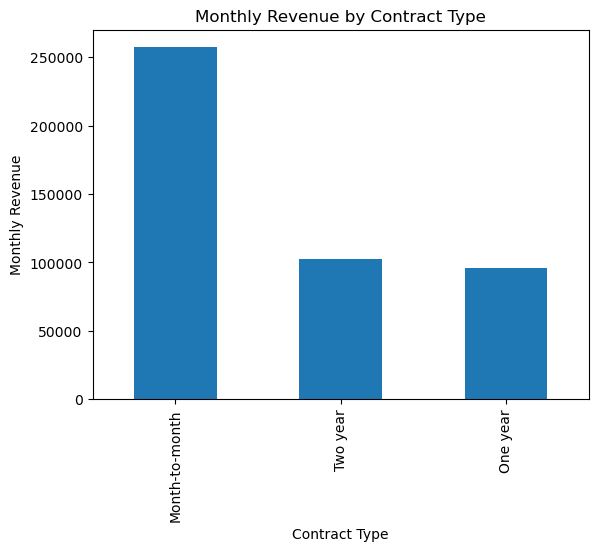

In [6]:
revenue_by_contract.plot(kind='bar')
plt.title("Monthly Revenue by Contract Type")
plt.ylabel("Monthly Revenue")
plt.xlabel("Contract Type")
plt.show()

## Revenue by Contract Type
This breakdown shows how revenue is distributed across customer contract categories. Since the business analysis already showed that month-to-month customers churn more frequently, this comparison helps connect customer behavior to financial impact.

If a large portion of revenue comes from short-term customers, the business faces greater exposure to revenue instability.

In [7]:
churn_revenue_by_contract = churned.groupby('Contract')['MonthlyCharges'].sum().sort_values(ascending=False)
print(churn_revenue_by_contract)

Contract
Month-to-month    120847.10
One year           14118.45
Two year            4165.30
Name: MonthlyCharges, dtype: float64


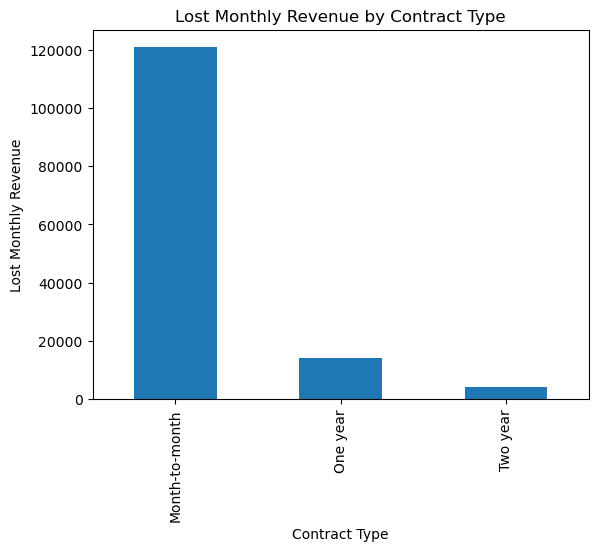

In [8]:
churn_revenue_by_contract.plot(kind='bar')
plt.title("Lost Monthly Revenue by Contract Type")
plt.ylabel("Lost Monthly Revenue")
plt.xlabel("Contract Type")
plt.show()

## Lost Revenue by Contract Type
This chart focuses only on churned customers and shows which contract groups contribute most to lost monthly revenue. If month-to-month customers account for the highest lost revenue, then reducing churn in that segment could have an immediate financial benefit.

In [9]:
avg_monthly_charge_churned = churned['MonthlyCharges'].mean()
avg_monthly_charge_active = active['MonthlyCharges'].mean()

print("Average Monthly Charge - Active Customers:", round(avg_monthly_charge_active, 2))
print("Average Monthly Charge - Churned Customers:", round(avg_monthly_charge_churned, 2))

Average Monthly Charge - Active Customers: 61.31
Average Monthly Charge - Churned Customers: 74.44


## Average Revenue per Customer
Comparing the average monthly charges of active and churned customers helps determine whether churn is concentrated among lower-value or higher-value customers.

If churned customers have relatively high monthly charges, the business may be losing some of its more valuable customers, which increases the urgency of retention efforts.

In [10]:
revenue_by_payment = df.groupby('PaymentMethod')['MonthlyCharges'].sum().sort_values(ascending=False)
print(revenue_by_payment)

PaymentMethod
Electronic check             180345.0
Bank transfer (automatic)    103631.0
Credit card (automatic)      101175.8
Mailed check                  70509.2
Name: MonthlyCharges, dtype: float64


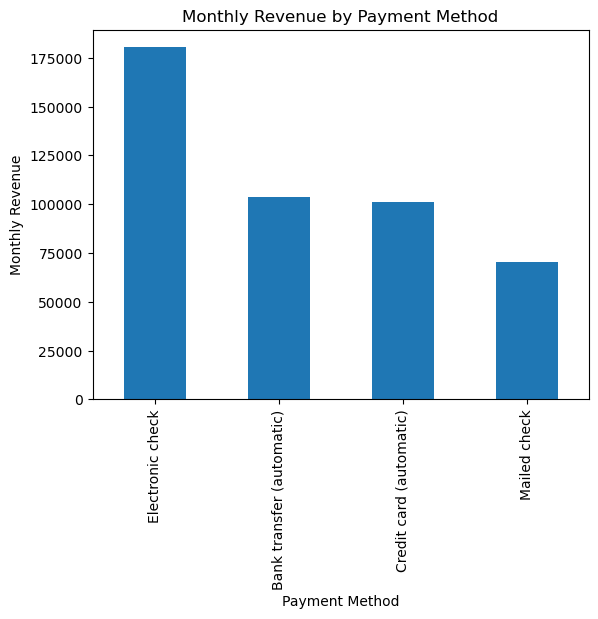

In [11]:
revenue_by_payment.plot(kind='bar')
plt.title("Monthly Revenue by Payment Method")
plt.ylabel("Monthly Revenue")
plt.xlabel("Payment Method")
plt.show()

In [12]:
lost_revenue_by_payment = churned.groupby('PaymentMethod')['MonthlyCharges'].sum().sort_values(ascending=False)
print(lost_revenue_by_payment)

PaymentMethod
Electronic check             84288.75
Bank transfer (automatic)    20091.90
Credit card (automatic)      17946.60
Mailed check                 16803.60
Name: MonthlyCharges, dtype: float64


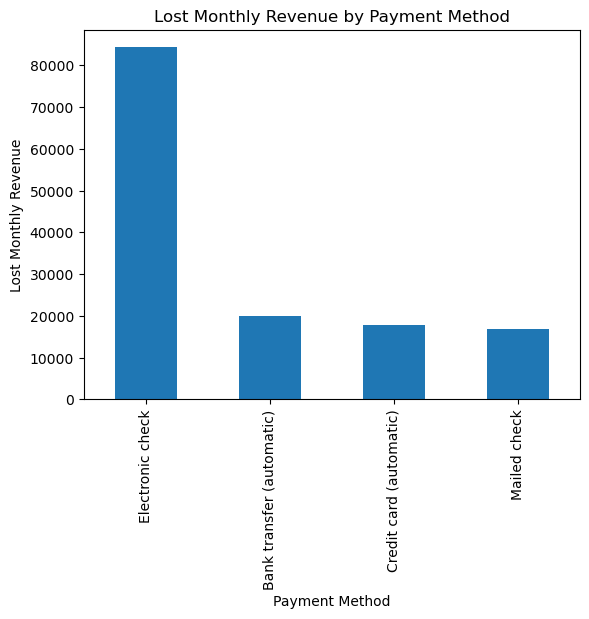

In [13]:
lost_revenue_by_payment.plot(kind='bar')
plt.title("Lost Monthly Revenue by Payment Method")
plt.ylabel("Lost Monthly Revenue")
plt.xlabel("Payment Method")
plt.show()

## Revenue by Payment Method
This section links payment behavior to financial performance. If electronic check customers account for a large share of lost revenue, then encouraging automatic payment methods may help reduce both churn and revenue leakage.

## Final Conclusion
The financial analysis shows that customer churn has a significant revenue impact. A notable portion of monthly revenue is associated with customers who eventually leave the company.

The results suggest that the business should prioritize retention strategies in the segments already identified as high risk: month-to-month customers, electronic check users, and newer customers with short tenure.

Reducing churn in these segments would not only improve customer retention but also protect monthly revenue and strengthen financial stability.